# ANALISI TEMPORALE DEGLI INCIDENTI STRADALI (2001-2024) 

L' obiettivo di questo notebook è l' analisi a livello temporale degli incidenti stradali in Italia nel periodo 2001-2024, con l' intendo di individuare eventuali trend e valutando se sia possibile descriverli tramite un modello di regressione lineare.

# LIBRERIE

Importazione delle librerie di utilità principale

In [351]:
import pandas as pd
import os
import numpy as np
import FUNCTIONS as fn

#grafici
import seaborn as sns
import matplotlib 
import matplotlib.pyplot as plt

#Regressioni lineari
import statsmodels.api as sm
#vif
from statsmodels.stats.outliers_influence import variance_inflation_factor

#Clustering
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import mean_absolute_error


# CARICAMENTO DF di PARTENZA

Carico i df con le osservazioni separate, incidenti, feriti e morti. Tutti questi presentano registrazioni dall' anno 2001 al 2024

In [352]:
os.getcwd()

'c:\\Users\\eliav\\Desktop\\Road_accidents_analysis\\Notebooks'

In [353]:
os.listdir()

['00_fetching.ipynb',
 '01cleaning_overview.ipynb',
 '02a.EDA_&_Temporal_analysis.ipynb',
 '02b_EDA_Municipality_analysis_aggregate_01_24.ipynb',
 '03b_Test.ipynb',
 'FUNCTIONS.py',
 '__pycache__']

In [354]:
os.listdir('../Data/Df_clean')

['df_feriti_from_01_to_24.csv',
 'df_final_from_01_to_24_clean.csv',
 'df_incidenti_from_01_to_24.csv',
 'df_morti_from_01_to_24.csv']

In [355]:
df_accidents= pd.read_csv ("../Data/Df_clean/df_incidenti_from_01_to_24.csv")
df_accidents.info()

<class 'pandas.DataFrame'>
RangeIndex: 191184 entries, 0 to 191183
Data columns (total 14 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   TIME_PERIOD          191184 non-null  int64  
 1   ID_COMUNE_OG         191184 non-null  int64  
 2   ID_COMUNE            190900 non-null  float64
 3   COMUNE               190900 non-null  str    
 4   ID_REGIONE           190900 non-null  float64
 5   REGIONE              190900 non-null  str    
 6   CAPOLUOGO REGIONE    190900 non-null  float64
 7   ID_PROVINCIA         190900 non-null  float64
 8   CAPOLUOGO PROVINCIA  190900 non-null  float64
 9   DATA_TYPE            191184 non-null  str    
 10  RESULT               191184 non-null  str    
 11  OBS_VALUE            191184 non-null  int64  
 12  RESIDENTI            190900 non-null  float64
 13  SUPERFICIE (KMQ)     190900 non-null  float64
dtypes: float64(7), int64(3), str(4)
memory usage: 20.4 MB


In [356]:
# int_columns = [
#     "TIME_PERIOD",
#     "ID_COMUNE_OG",
#     "ID_COMUNE",
#     "ID_REGIONE",
#     "CAPOLUOGO REGIONE",
#     "ID_PROVINCIA",
#     "CAPOLUOGO PROVINCIA",
#     "RESIDENTI"
# ]

# for col in int_columns:
#     df_accidents[col] = df_accidents[col].astype("Int64")

In [357]:
df_accidents.info()

<class 'pandas.DataFrame'>
RangeIndex: 191184 entries, 0 to 191183
Data columns (total 14 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   TIME_PERIOD          191184 non-null  int64  
 1   ID_COMUNE_OG         191184 non-null  int64  
 2   ID_COMUNE            190900 non-null  float64
 3   COMUNE               190900 non-null  str    
 4   ID_REGIONE           190900 non-null  float64
 5   REGIONE              190900 non-null  str    
 6   CAPOLUOGO REGIONE    190900 non-null  float64
 7   ID_PROVINCIA         190900 non-null  float64
 8   CAPOLUOGO PROVINCIA  190900 non-null  float64
 9   DATA_TYPE            191184 non-null  str    
 10  RESULT               191184 non-null  str    
 11  OBS_VALUE            191184 non-null  int64  
 12  RESIDENTI            190900 non-null  float64
 13  SUPERFICIE (KMQ)     190900 non-null  float64
dtypes: float64(7), int64(3), str(4)
memory usage: 20.4 MB


In [358]:
df_wounded= pd.read_csv ("../Data/Df_clean/df_feriti_from_01_to_24.csv")
df_wounded.info()

<class 'pandas.DataFrame'>
RangeIndex: 191184 entries, 0 to 191183
Data columns (total 14 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   TIME_PERIOD          191184 non-null  int64  
 1   ID_COMUNE_OG         191184 non-null  int64  
 2   ID_COMUNE            190900 non-null  float64
 3   COMUNE               190900 non-null  str    
 4   ID_REGIONE           190900 non-null  float64
 5   REGIONE              190900 non-null  str    
 6   CAPOLUOGO REGIONE    190900 non-null  float64
 7   ID_PROVINCIA         190900 non-null  float64
 8   CAPOLUOGO PROVINCIA  190900 non-null  float64
 9   DATA_TYPE            191184 non-null  str    
 10  RESULT               191184 non-null  str    
 11  OBS_VALUE            191184 non-null  int64  
 12  RESIDENTI            190900 non-null  float64
 13  SUPERFICIE (KMQ)     190900 non-null  float64
dtypes: float64(7), int64(3), str(4)
memory usage: 20.4 MB


In [359]:
df_deaths= pd.read_csv ("../Data/Df_clean/df_morti_from_01_to_24.csv")
df_deaths

,TIME_PERIOD,ID_COMUNE_OG,ID_COMUNE,COMUNE,ID_REGIONE,REGIONE,CAPOLUOGO REGIONE,ID_PROVINCIA,CAPOLUOGO PROVINCIA,DATA_TYPE,RESULT,OBS_VALUE,RESIDENTI,SUPERFICIE (KMQ)
0,2001,1001,1001.0,Agliè,1.0,Piemonte,0.0,1.0,0.0,morti_e_feriti,morti,0,2557.0,13.1462
1,2002,1001,1001.0,Agliè,1.0,Piemonte,0.0,1.0,0.0,morti_e_feriti,morti,0,2538.0,13.1462
2,2003,1001,1001.0,Agliè,1.0,Piemonte,0.0,1.0,0.0,morti_e_feriti,morti,0,2588.0,13.1462
3,2004,1001,1001.0,Agliè,1.0,Piemonte,0.0,1.0,0.0,morti_e_feriti,morti,0,2679.0,13.1462
4,2005,1001,1001.0,Agliè,1.0,Piemonte,0.0,1.0,0.0,morti_e_feriti,morti,0,2674.0,13.1462
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
191179,2020,111107,111107.0,Villaspeciosa,20.0,Sardegna,0.0,111.0,0.0,morti_e_feriti,morti,0,2549.0,27.1937
191180,2021,111107,111107.0,Villaspeciosa,20.0,Sardegna,0.0,111.0,0.0,morti_e_feriti,morti,0,2536.0,27.1943
191181,2022,111107,111107.0,Villaspeciosa,20.0,Sardegna,0.0,111.0,0.0,morti_e_feriti,morti,0,2575.0,27.1943
191182,2023,111107,111107.0,Villaspeciosa,20.0,Sardegna,0.0,111.0,0.0,morti_e_feriti,morti,0,2616.0,27.1943


# EDA

## FEATURE ENGINEERING

In [360]:
# Incidenti per anno
incidenti = (df_accidents.groupby("TIME_PERIOD", as_index=False)["OBS_VALUE"].sum().rename(columns={"OBS_VALUE": "Incidenti"}))

# Morti per anno
morti = (df_deaths.groupby("TIME_PERIOD", as_index=False)["OBS_VALUE"].sum().rename(columns={"OBS_VALUE": "Morti"}))

# Feriti per anno
feriti = (df_wounded.groupby("TIME_PERIOD", as_index=False)["OBS_VALUE"].sum().rename(columns={"OBS_VALUE": "Feriti"}))

# Merge dei tre DataFrame
df_total_obs_by_year = (incidenti.merge(morti, on="TIME_PERIOD").merge(feriti, on="TIME_PERIOD"))

## DATA OVERVIEW e CLEANING CHECK

Prima di iniziare con l' analisi esplorativa ricontrollo la pulizia dei dati del mio df

In [361]:
df_total_obs_by_year.head()

,TIME_PERIOD,Incidenti,Morti,Feriti
0,2001,263100,7096,373286
1,2002,265402,6980,378491
2,2003,252271,6563,356475
3,2004,243490,6122,343179
4,2005,240011,5818,334858


In [362]:
df_total_obs_by_year.info()

<class 'pandas.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   TIME_PERIOD  24 non-null     int64
 1   Incidenti    24 non-null     int64
 2   Morti        24 non-null     int64
 3   Feriti       24 non-null     int64
dtypes: int64(4)
memory usage: 900.0 bytes


In [363]:
df_total_obs_by_year.shape

(24, 4)

In [364]:
print("Dati duplicati:",df_total_obs_by_year.duplicated().sum())
print("-"*40)
print("Dati nulli:\n", df_total_obs_by_year.isna().sum())


Dati duplicati: 0
----------------------------------------
Dati nulli:
 TIME_PERIOD    0
Incidenti      0
Morti          0
Feriti         0
dtype: int64


In [365]:
df_total_obs_by_year.dtypes

TIME_PERIOD    int64
Incidenti      int64
Morti          int64
Feriti         int64
dtype: object

## STATISTICA DESCRITTIVA

Voglio capire la distribuzione dei dati e vedere se ci sono punti di analisi interessanti

In [366]:
df_total_obs_by_year.describe().round()

,TIME_PERIOD,Incidenti,Morti,Feriti
count,24.0,24.0,24.0,24.0
mean,2012.0,199131.0,4248.0,279543.0
std,7.0,38475.0,1408.0,57003.0
min,2001.0,118298.0,2395.0,159248.0
25%,2007.0,173161.0,3256.0,242535.0
50%,2012.0,184944.0,3590.0,262478.0
75%,2018.0,232684.0,5266.0,327626.0
max,2024.0,265402.0,7096.0,378491.0


# CLASSIFICHE

In [367]:
display(df_total_obs_by_year.sort_values("Incidenti", ascending=False).head(1)) #anno con più incidenti --> 2002
display(df_total_obs_by_year.sort_values("Morti", ascending=False).head(1)) #anno con più morti --> 2001
display(df_total_obs_by_year.sort_values("Feriti", ascending=False).head(1)) ##anno con più feriti --> 2002

,TIME_PERIOD,Incidenti,Morti,Feriti
1,2002,265402,6980,378491


,TIME_PERIOD,Incidenti,Morti,Feriti
0,2001,263100,7096,373286


,TIME_PERIOD,Incidenti,Morti,Feriti
1,2002,265402,6980,378491


In [368]:
#ANNO E COMUNE CON PIU' INCIDENTI
display(df_accidents.sort_values(by="OBS_VALUE",ascending=False).head(1))
#ANNO E COMUNE CON PIU' FERITI
display(df_wounded.sort_values(by="OBS_VALUE",ascending=False).head(1))
#ANNO E COMUNE CON PIU' MORTI
display(df_deaths.sort_values(by="OBS_VALUE",ascending=False).head(1))

,TIME_PERIOD,ID_COMUNE_OG,ID_COMUNE,COMUNE,ID_REGIONE,REGIONE,CAPOLUOGO REGIONE,ID_PROVINCIA,CAPOLUOGO PROVINCIA,DATA_TYPE,RESULT,OBS_VALUE,RESIDENTI,SUPERFICIE (KMQ)
116198,2004,58091,58091.0,Roma,12.0,Lazio,1.0,58.0,1.0,incidenti_stradali,incidenti,23135,2566690.0,1287.3371


,TIME_PERIOD,ID_COMUNE_OG,ID_COMUNE,COMUNE,ID_REGIONE,REGIONE,CAPOLUOGO REGIONE,ID_PROVINCIA,CAPOLUOGO PROVINCIA,DATA_TYPE,RESULT,OBS_VALUE,RESIDENTI,SUPERFICIE (KMQ)
116198,2004,58091,58091.0,Roma,12.0,Lazio,1.0,58.0,1.0,morti_e_feriti,feriti,30254,2566690.0,1287.3371


,TIME_PERIOD,ID_COMUNE_OG,ID_COMUNE,COMUNE,ID_REGIONE,REGIONE,CAPOLUOGO REGIONE,ID_PROVINCIA,CAPOLUOGO PROVINCIA,DATA_TYPE,RESULT,OBS_VALUE,RESIDENTI,SUPERFICIE (KMQ)
116196,2002,58091,58091.0,Roma,12.0,Lazio,1.0,58.0,1.0,morti_e_feriti,morti,363,2544815.0,1287.3371


In [369]:
# #ANNO E COMUNE CON PIU' INCIDENTI PRO CAPITE
# display(df_accidents.sort_values(by="INCIDENTI_PRO_CAPITE(1000)",ascending=False).head(1))
# #ANNO E COMUNE CON PIU' FERITI PRO CAPITE
# display(df_wounded.sort_values(by="FERITI_PRO_CAPITE(1000)",ascending=False).head(1))
# #ANNO E COMUNE CON PIU' MORTI PRO CAPITE
# display(df_deaths.sort_values(by="MORTI_PRO_CAPITE(1000)",ascending=False).head(1))

In [370]:
### CI SONO COMUNI CHE HANNO AVUTO ANDAMENTO MOLTO DIVERSO NEGLI ANNI TRA I PRIMI RECORD?
df_accidents.groupby(["TIME_PERIOD", "COMUNE"])["OBS_VALUE"].sum().sort_values(ascending=False).head(20)

TIME_PERIOD  COMUNE
2004         Roma      23135
2001         Roma      22220
2005         Roma      21902
2006         Roma      21452
2002         Roma      21330
2003         Roma      20426
2007         Roma      19960
2009         Roma      18561
2010         Roma      18496
2011         Roma      18235
2008         Roma      18181
2001         Milano    18026
2002         Milano    17787
2003         Milano    17054
2004         Milano    16561
2012         Roma      15783
2005         Milano    15443
2006         Milano    15332
2013         Roma      14622
2007         Milano    14622
Name: OBS_VALUE, dtype: int64

## ANALISI UNIVARIATA (istogrammi, boxplot, barchart)

### Histograms & Boxplots

N.B. Essendo il dataset composto da sole 24 osservazioni aggregate per anno, questi grafici hanno un valore principalmente descrittivo. L'interpretazione principale del fenomeno si baserà invece sull'andamento temporale e sulla regressione lineare.

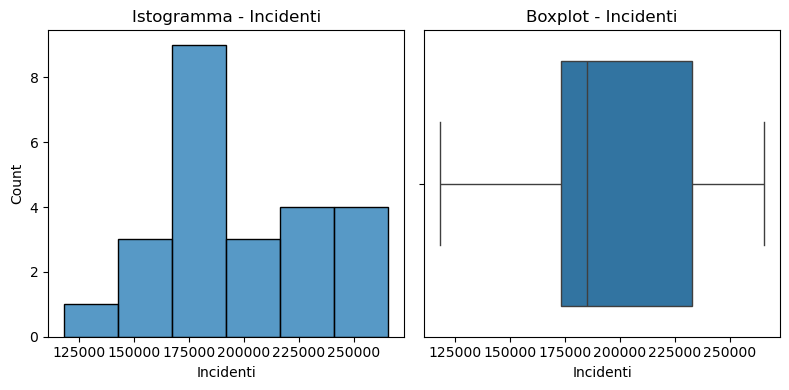

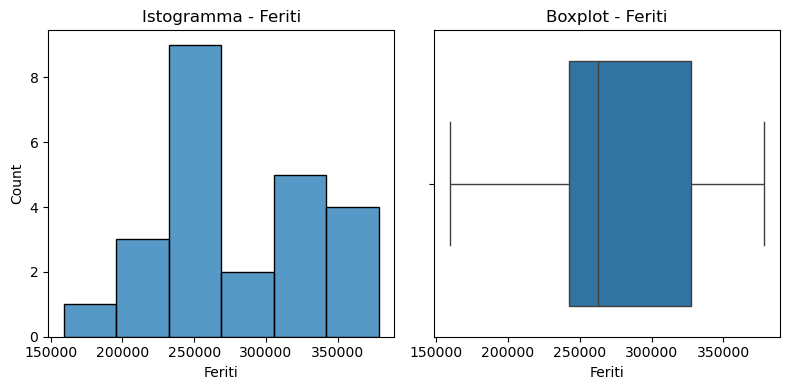

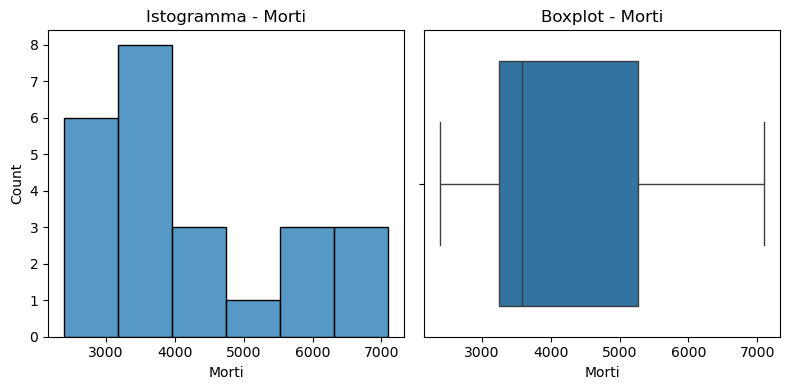

In [371]:
for col in ["Incidenti", "Feriti", "Morti"]:
    fn.plot_distribuzione(df_total_obs_by_year, col)

### Barplots

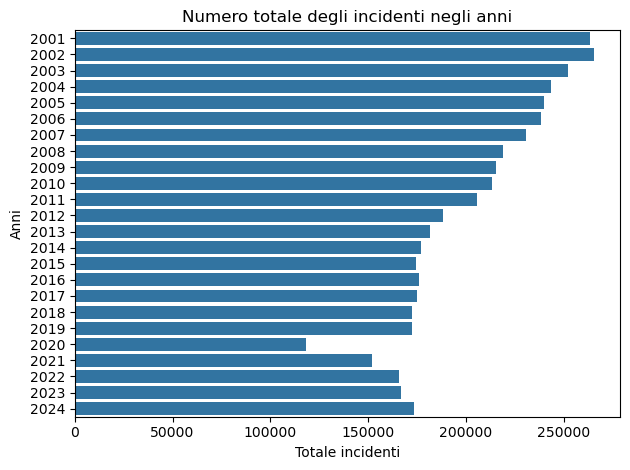

In [372]:
sns.barplot(data=df_total_obs_by_year,x="Incidenti",y="TIME_PERIOD", orient="h")
plt.title("Numero totale degli incidenti negli anni")
plt.xlabel("Totale incidenti")
plt.ylabel("Anni")
plt.tight_layout()
plt.show()

## ANALISI BIVARIATA (scatterplot, linesplot..)

### Scatterplot

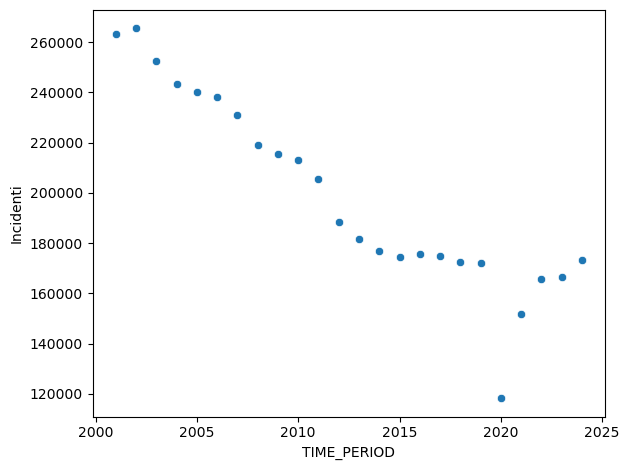

In [373]:
#guardo l' andamento totale degli incidenti anno per anno 
sns.scatterplot(df_total_obs_by_year, x="TIME_PERIOD", y="Incidenti")
plt.tight_layout()
plt.show()

#VEDENDO CHE L' ANDAMENTO E' SIMILE AD UNA RETTA (A PARTE IL 2020 CHE RAPPRESENTA UN' ANOMALIA)
#PENSO DI POTER FARE UNA REGRESSIONE LINEARE PER PROVARE A PREVEDERE GLI ANNI SUCCESSIVI AL 2024

### Linesplot

Come varia l' andamento degli incidenti , morti e feriti negli anni? (la scala dei numeri verrà resa in %)

-L' andamento rispetto al 2001 è descrescente con un valore anomalo corrispondente all' anno 2020 per tutte e tre le variabili prese in considerazione (incidenti, morti, feriti). Questo potrebbe spiegarsi con la scarsa mobilità durante il tempo della pandemia.

In [374]:
# Faccio una normalizzazione rispetto al primo anno (2001). Quindi il 2001 rappresenterà il 100%
trend_norm = df_total_obs_by_year.copy()

for col in ["Incidenti", "Feriti", "Morti"]:
    trend_norm[col] = trend_norm[col] / trend_norm[col].iloc[0] * 100

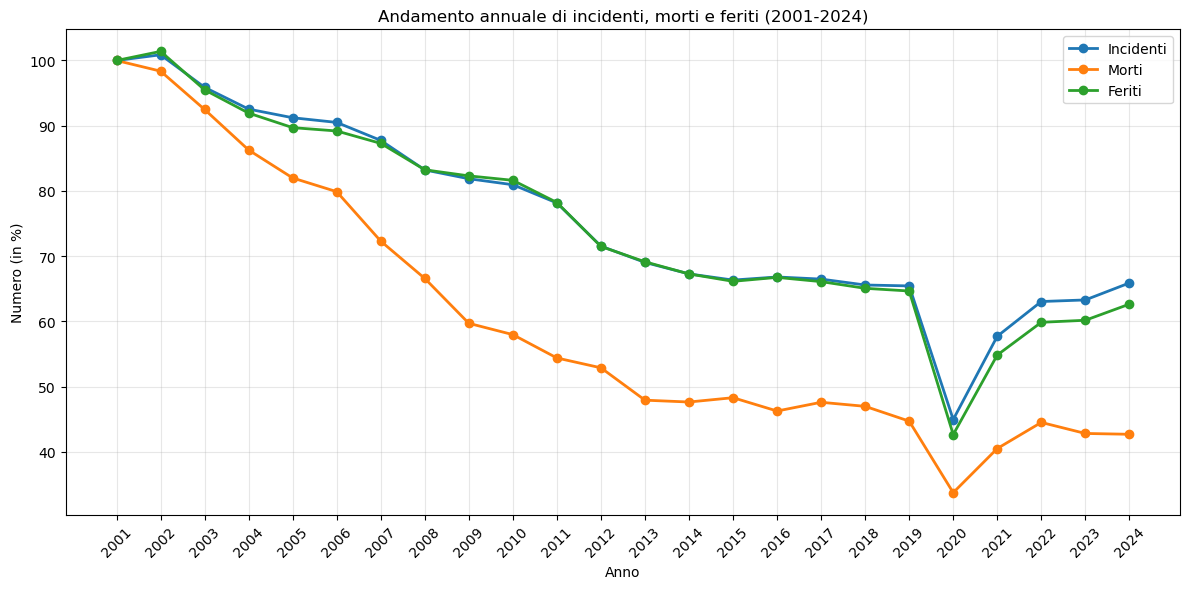

In [375]:
plt.figure(figsize=(12,6))

plt.plot(trend_norm["TIME_PERIOD"],trend_norm["Incidenti"],label="Incidenti",linewidth=2, marker="o")
plt.plot(trend_norm["TIME_PERIOD"],trend_norm["Morti"],label="Morti",linewidth=2, marker="o")
plt.plot(trend_norm["TIME_PERIOD"],trend_norm["Feriti"],label="Feriti",linewidth=2, marker="o")

plt.title("Andamento annuale di incidenti, morti e feriti (2001-2024)")
plt.xlabel("Anno")
plt.ylabel("Numero (in %)") #--> considerando il 2001 come 100% si vedrà l' andamento in % dei fenomeni partendo da quel risultato
plt.xticks(trend_norm["TIME_PERIOD"], rotation=45)
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

#RAPPRESENTANDO IL 2001 IL 100% SI PUò NOTARE COME IL 2024 ABBIA ASSUNTO UN VALORE INTORNO AL 65%, DUNQUE CI FA CAPIRE CHE 
#RISPETTO AL 2001 NEL 2024 CI SONO STATI IL 35% DI INCIDENTI IN MENO

### ANALISI DEL TREND TEMPORALE --> Variazione (%) anno su anno degli incidenti, feriti e morti

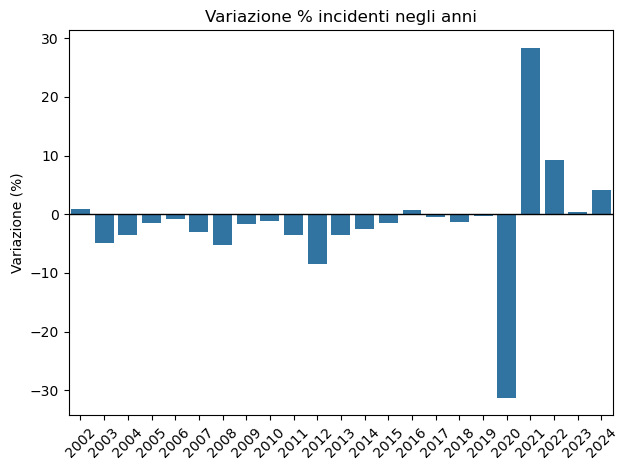

In [376]:
#Calcolo la variazione percentuale rispetto all'anno precedente del numero totale di incidenti.
df_total_obs_by_year["VAR_INCIDENTI"] = (df_total_obs_by_year["Incidenti"].pct_change()*100)

#dal momento in cui il 2001 è il primo anno e quindi non ha variazione (avrà valore nan) posso eliminarlo così

drop_2001 = df_total_obs_by_year.dropna(subset=["VAR_INCIDENTI"])

sns.barplot(drop_2001, x="TIME_PERIOD", y="VAR_INCIDENTI")
plt.xlabel("")
plt.ylabel("Variazione (%)")
plt.title("Variazione % incidenti negli anni")
plt.xticks(rotation=45) 
plt.axhline(0, color="black", linewidth=1) #aggiunge una linea sullo 0
plt.tight_layout()
plt.show()

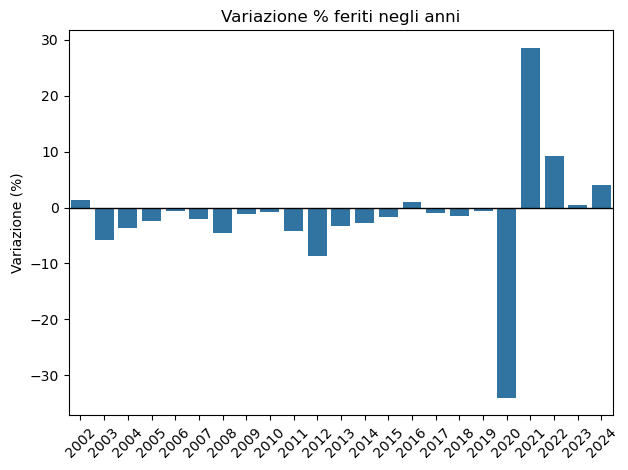

In [377]:
df_total_obs_by_year["VAR_FERITI"] = (
    df_total_obs_by_year["Feriti"].pct_change()*100
)

#dal momento in cui il 2001 è il primo anno e quindi non ha variazione (avrà valore nan) posso eliminarlo così

drop_2001 = df_total_obs_by_year.dropna(subset=["VAR_FERITI"])

sns.barplot(drop_2001, x="TIME_PERIOD", y="VAR_FERITI")
plt.xlabel("")
plt.ylabel("Variazione (%)")
plt.title("Variazione % feriti negli anni")
plt.xticks(rotation=45) 
plt.axhline(0, color="black", linewidth=1) #aggiunge una linea sullo 0
plt.tight_layout()
plt.show()

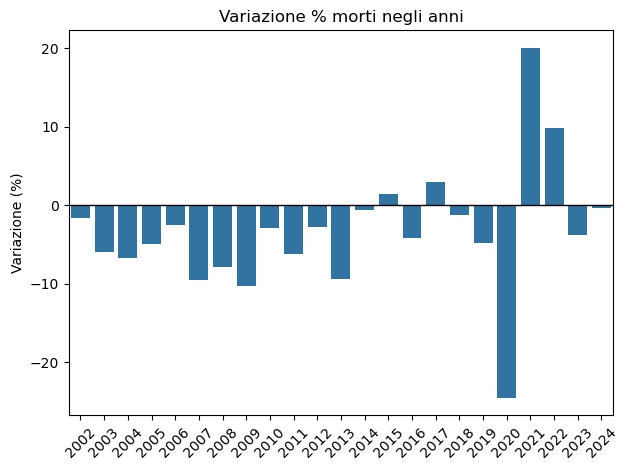

In [378]:
df_total_obs_by_year["VAR_MORTI"] = (
    df_total_obs_by_year["Morti"].pct_change()*100
)

#dal momento in cui il 2001 è il primo anno e quindi non ha variazione (avrà valore nan) posso eliminarlo così

drop_2001 = df_total_obs_by_year.dropna(subset=["VAR_MORTI"])

sns.barplot(drop_2001, x="TIME_PERIOD", y="VAR_MORTI")
plt.xlabel("")
plt.ylabel("Variazione (%)")
plt.title("Variazione % morti negli anni")
plt.xticks(rotation=45) 
plt.axhline(0, color="black", linewidth=1) #aggiunge una linea sullo 0
plt.tight_layout()
plt.show()

## CORRELAZIONI VARIABILI

In [379]:
corr=df_total_obs_by_year.corr()
corr

#QUESTE CORRELAZIONI CONFERMANO CIò CHE SI ERA VISTO NEL LINE PLOT, INFATTI INCIDENTI MORTI E FERITI SONO CORRELATI 
#NEGATIVAMENTE CON IL PERIODO, NEL LINE PLOT SI VEDEVA INFATTI COME QUESTI DIMINUISCANO NEL TEMPO.

,TIME_PERIOD,Incidenti,Morti,Feriti,VAR_INCIDENTI,VAR_FERITI,VAR_MORTI
TIME_PERIOD,1.000000,-0.928655,-0.924974,-0.941588,0.198139,0.175914,0.298534
Incidenti,-0.928655,1.000000,0.962793,0.997491,0.031820,0.057927,-0.113441
Morti,-0.924974,0.962793,1.000000,0.953979,-0.040637,-0.023651,-0.139976
Feriti,-0.941588,0.997491,0.953979,1.000000,0.007634,0.035206,-0.134348
VAR_INCIDENTI,0.198139,0.031820,-0.040637,0.007634,1.000000,0.998267,0.907689
VAR_FERITI,0.175914,0.057927,-0.023651,0.035206,0.998267,1.000000,0.896658
VAR_MORTI,0.298534,-0.113441,-0.139976,-0.134348,0.907689,0.896658,1.000000


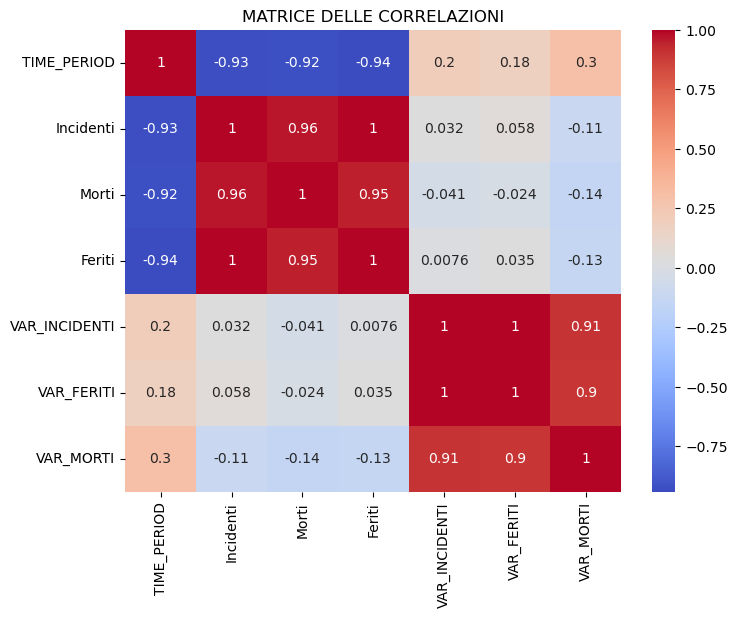

In [380]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr,annot=True,cmap="coolwarm")

plt.title("MATRICE DELLE CORRELAZIONI")
plt.show()

# REGRESSIONI LINEARI

Dopo aver analizzato l' evoluzione del fenomeno a livello descrittivo e grafico, si procede con la creazione di un modello di regressione lineare per verificare se il trend osservato, sia esso crescente che decrescente, possa essere inscritto in un modello corrispondente ad una retta.

## REGRESSIONE LINEARE ANDAMENTO INCIDENTI A LIVELLO NAZIONALE

Come sarà l' andamento degli incidenti nel futuro prendendo come predittore gli anni?

-Prevedendo tramite la regressione gli incidenti fino al 2030, viene mostrato un andamento decrescente con il passare degli anni.

In [381]:
df_total_obs_by_year[["TIME_PERIOD", "Incidenti"]].corr()

,TIME_PERIOD,Incidenti
TIME_PERIOD,1.000000,-0.928655
Incidenti,-0.928655,1.000000


In [382]:
df_total_obs_by_year=df_total_obs_by_year.dropna(subset=["TIME_PERIOD", "Incidenti"]).copy()

X = df_total_obs_by_year["TIME_PERIOD"] #variabile indipendente-predittore
y = df_total_obs_by_year["Incidenti"] #variabile dipendente, quella che si vorrebbe predirre in base all' x

X = sm.add_constant(X)

model1 = sm.OLS(y, X).fit()
print(model1.summary())



                            OLS Regression Results                            
Dep. Variable:              Incidenti   R-squared:                       0.862
Model:                            OLS   Adj. R-squared:                  0.856
Method:                 Least Squares   F-statistic:                     137.9
Date:                Wed, 09 Sep 2026   Prob (F-statistic):           6.02e-11
Time:                        21:12:58   Log-Likelihood:                -263.13
No. Observations:                  24   AIC:                             530.3
Df Residuals:                      22   BIC:                             532.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        1.037e+07   8.66e+05     11.972      

In [383]:
future = pd.DataFrame({"TIME_PERIOD": [2025, 2026, 2027, 2028, 2029, 2030]})

future=sm.add_constant(future) #devo aggiungere la costante a tutti i valori di future poichè non è più semplicemente un array in cui aggiungevo io a mano 1 per avere anche la seconda dimensione

print(X.head())
print(X.columns)
print(future.head())
print(future.columns) #con queste ultime 4 righe vedo che i miei due df hanno tutte e due la stessa dimensione (cioè 2)

   const  TIME_PERIOD
0    1.0         2001
1    1.0         2002
2    1.0         2003
3    1.0         2004
4    1.0         2005
Index(['const', 'TIME_PERIOD'], dtype='str')
   const  TIME_PERIOD
0    1.0         2025
1    1.0         2026
2    1.0         2027
3    1.0         2028
4    1.0         2029
Index(['const', 'TIME_PERIOD'], dtype='str')


In [384]:
future["Predicted"] = model1.predict(future)

print(future.round(2))

   const  TIME_PERIOD  Predicted
0    1.0         2025  135969.29
1    1.0         2026  130916.37
2    1.0         2027  125863.44
3    1.0         2028  120810.51
4    1.0         2029  115757.59
5    1.0         2030  110704.66


In [385]:
model1.params
# 1.034232e+07 - intercetta
# -5.040221e+03 - coefficiente angolare (slope)

const          1.036815e+07
TIME_PERIOD   -5.052927e+03
dtype: float64

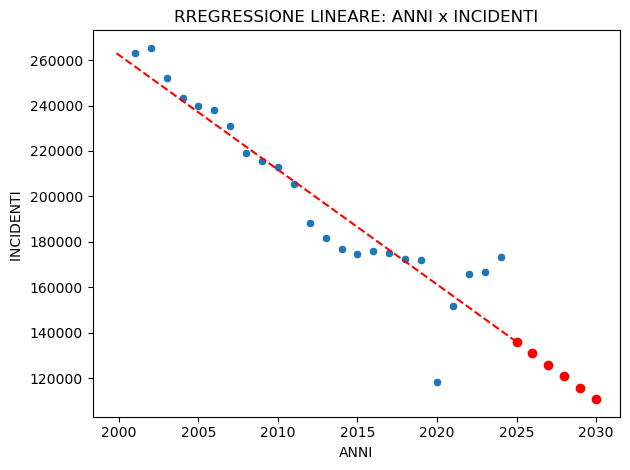

In [386]:
#Grafico della retta di regressione

#Coefficienti della retta
intercept=model1.params["const"]
slope=model1.params["TIME_PERIOD"]

sns.scatterplot(x="TIME_PERIOD",y="Incidenti",
                data=df_total_obs_by_year)
plt.xlabel("ANNI")
plt.ylabel("INCIDENTI ")
plt.title("RREGRESSIONE LINEARE: ANNI x INCIDENTI")


#Limiti asse X
axes = plt.gca()
x_vals = np.array(axes.get_xlim())

#Eq della retta
y_vals = intercept + slope * x_vals

#Plot della retta di regressione
plt.plot(x_vals, y_vals, "--", color="r")

#Plot della previsione
plt.plot(future["TIME_PERIOD"], future["Predicted"], "ro")

plt.tight_layout() #per uniformare gli spazi
plt.show()

In [387]:

# il modello descrive bene il trend generale;
# non cattura completamente l'andamento della serie;
# ciò è coerente con la presenza di eventi eccezionali (COVID) e con la natura temporale dei dati.

È stata applicata una regressione lineare semplice utilizzando l'anno come variabile indipendente e il numero totale di incidenti come variabile dipendente, con l'obiettivo di valutare l'eventuale presenza di un trend temporale e stimare l'andamento degli incidenti negli anni successivi.

N.B. Il 2020 influenza la stima della regressione essendo un evento anomalo ma comunque reale, ciononostante voglio provare a creare un modello in cui il 2020 viene estraniato.

                            OLS Regression Results                            
Dep. Variable:              Incidenti   R-squared:                       0.902
Model:                            OLS   Adj. R-squared:                  0.898
Method:                 Least Squares   F-statistic:                     194.2
Date:                Wed, 09 Sep 2026   Prob (F-statistic):           4.42e-12
Time:                        21:12:58   Log-Likelihood:                -246.14
No. Observations:                  23   AIC:                             496.3
Df Residuals:                      21   BIC:                             498.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const         9.75e+06   6.85e+05     14.229      

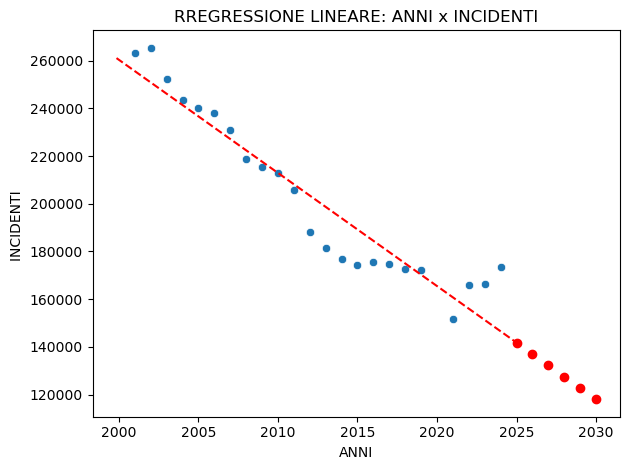

In [388]:
df_no2020 = df_total_obs_by_year[df_total_obs_by_year["TIME_PERIOD"] != 2020]

P = df_no2020["TIME_PERIOD"] #variabile indipendente-predittore
y = df_no2020["Incidenti"] #variabile dipendente, quella che si vorrebbe predirre in base all' x

P = sm.add_constant(P)

model2 = sm.OLS(y, P).fit()
print(model2.summary())


future = pd.DataFrame({
    "TIME_PERIOD": [2025, 2026, 2027, 2028, 2029, 2030]})

future=sm.add_constant(future) #devo aggiungere la costante a tutti i valori di future poichè non è più semplicemente un array in cui aggiungevo io a mano 1 per avere anche la seconda dimensione

print(P.head())
print(P.columns)
print(future.head())
print(future.columns) #con queste ultime 4 righe vedo che i miei due df hanno tutte e due la stessa dimensione (cioè 2)

future["Predicted"] = model2.predict(future)
print(future)

print(model2.params)
# 9.726960e+06 - intercetta
# 4.733479e+03 - coefficiente angolare (slope)

#Grafico della retta di regressione

#Coefficienti della retta
intercept=model2.params["const"]
slope=model2.params["TIME_PERIOD"]

sns.scatterplot(x="TIME_PERIOD",y="Incidenti",
                data=df_no2020)
plt.xlabel("ANNI")
plt.ylabel("INCIDENTI ")
plt.title("RREGRESSIONE LINEARE: ANNI x INCIDENTI")


#Limiti asse X
axes = plt.gca()
x_vals = np.array(axes.get_xlim())

#Eq della retta
y_vals = intercept + slope * x_vals

#Plot della retta di regressione
plt.plot(x_vals, y_vals, "--", color="r")

#Plot della previsione
plt.plot(future["TIME_PERIOD"], future["Predicted"], "ro")

plt.tight_layout() #per uniformare gli spazi
plt.show()

**Dal modello con 2020:**

 R-squared = 0.860: l' anno spiega circa l' 86% della variabilità degli incidenti. (Questo è minore rispetto al modello senza il 2020 appunto perchè il 2020 è un anomalia che fa variare la regressione)

 Coefficiente di TIME_PERIOD = -5040.2209: all' aumentare degli anni gli incidenti diminuiscono di 5000 circa

 P>|t| = 0.000: il coefficiente è statisticamente significativo.

 Quindi la relazione è forte e negativa (infatti diminuisce).

----------------------------------

**Dal modello SENZA 2020:**

 R-squared =  0.900: l' anno spiega circa il 90% della variabilità degli incidenti.

 Coefficiente di TIME_PERIOD = -4733: all' aumentare degli anni gli incidenti diminuiscono. Concorde con la regressione del modello con 2020

 P>|t| = 0.000: il coefficiente è statisticamente significativo.

 Quindi la relazione è forte e negativa (infatti diminuisce).

### RESIDUI, GRAFICO DEI RESIDUI E METRICHE MODELLO

Lo faccio però sul modello reale, quello che tiene in considerazione anche il 2020

In [389]:
#aggiungo una colonna nel df con le predizioni sul modello
df_total_obs_by_year["PRED_INCIDENTI"] = model1.predict(X) 

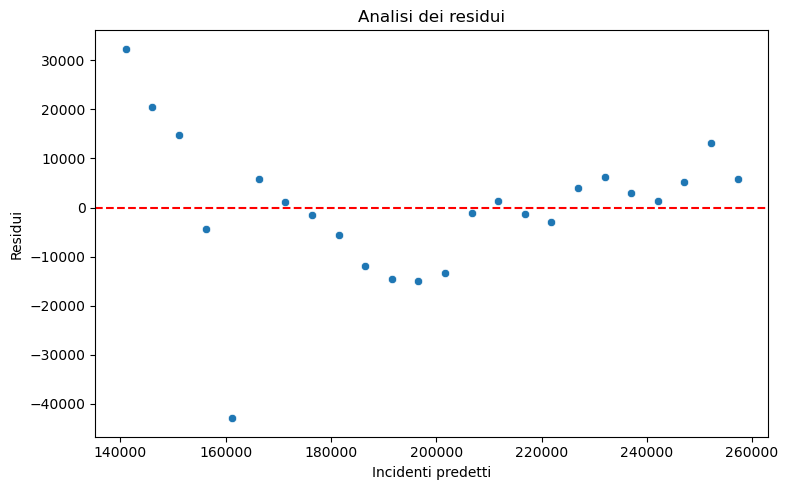

In [390]:
#aggiundo la colonna dei residui (cioè la differenza tra le osservazioni e le predizioni del modello) così da capire se il mio modello
# sta lavorando bene
df_total_obs_by_year["RESIDUI"] = (df_total_obs_by_year["Incidenti"] - df_total_obs_by_year["PRED_INCIDENTI"])

#GRAFICO DEI RESIDUI
plt.figure(figsize=(8,5))

sns.scatterplot(data=df_total_obs_by_year,x="PRED_INCIDENTI",y="RESIDUI")

plt.axhline(0,color="red",linestyle="--")

plt.xlabel("Incidenti predetti")
plt.ylabel("Residui")
plt.title("Analisi dei residui")

plt.tight_layout()
plt.show()


In [391]:
#VALUTAZIONE DEL MODELLO1 CON 2020 (MAE, RMSE,R2)
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)

mae = mean_absolute_error(
    df_total_obs_by_year["Incidenti"],
    df_total_obs_by_year["PRED_INCIDENTI"])

mse = mean_squared_error(
    df_total_obs_by_year["Incidenti"],
    df_total_obs_by_year["PRED_INCIDENTI"])
rmse = mse ** 0.5

r2 = r2_score(
    df_total_obs_by_year["Incidenti"],
    df_total_obs_by_year["PRED_INCIDENTI"])

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.3f}")

MAE : 9549.96
RMSE: 13971.39
R²  : 0.862


**MAE circa 9.848:** in media il modello sbaglia la stima del numero di incidenti di circa 9.848 incidenti all'anno. 

**$R^2$ = 0.860:** il modello spiega circa l'86% della variabilità del numero di incidenti nel periodo analizzato.

**RMSE circa 14.049** --> gli errori più grandi hanno un peso maggiore. È normale che sia superiore al MAE. La differenza tra MAE e RMSE suggerisce la presenza di alcuni errori di previsione più elevati, riconducibili anche all'eccezionalità del 2020.

Considerando che il numero di incidenti annuali è dell'ordine di 150.000–250.000, un MAE di circa 10.000 è abbastanza coerente con un modello lineare semplice.

## REGRESSIONE LINEARE MULTIPLA

come andranno gli incidenti nel futuro considerando gli anni, la popolazione e la densità abitativa dei comuni?

In [392]:
# df_accidents["LOG_INCIDENTI"] = np.log1p(df_accidents["OBS_VALUE"])
# df_accidents["LOG_RESIDENTI"] = np.log(df_accidents)

# df_accidents["LOG_RESIDENTI","LOG_INCIDENTI"].dta()

In [393]:
df_accidents

,TIME_PERIOD,ID_COMUNE_OG,ID_COMUNE,COMUNE,ID_REGIONE,REGIONE,CAPOLUOGO REGIONE,ID_PROVINCIA,CAPOLUOGO PROVINCIA,DATA_TYPE,RESULT,OBS_VALUE,RESIDENTI,SUPERFICIE (KMQ)
0,2001,1001,1001.0,Agliè,1.0,Piemonte,0.0,1.0,0.0,incidenti_stradali,incidenti,5,2557.0,13.1462
1,2002,1001,1001.0,Agliè,1.0,Piemonte,0.0,1.0,0.0,incidenti_stradali,incidenti,5,2538.0,13.1462
2,2003,1001,1001.0,Agliè,1.0,Piemonte,0.0,1.0,0.0,incidenti_stradali,incidenti,4,2588.0,13.1462
3,2004,1001,1001.0,Agliè,1.0,Piemonte,0.0,1.0,0.0,incidenti_stradali,incidenti,9,2679.0,13.1462
4,2005,1001,1001.0,Agliè,1.0,Piemonte,0.0,1.0,0.0,incidenti_stradali,incidenti,2,2674.0,13.1462
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
191179,2020,111107,111107.0,Villaspeciosa,20.0,Sardegna,0.0,111.0,0.0,incidenti_stradali,incidenti,2,2549.0,27.1937
191180,2021,111107,111107.0,Villaspeciosa,20.0,Sardegna,0.0,111.0,0.0,incidenti_stradali,incidenti,5,2536.0,27.1943
191181,2022,111107,111107.0,Villaspeciosa,20.0,Sardegna,0.0,111.0,0.0,incidenti_stradali,incidenti,1,2575.0,27.1943
191182,2023,111107,111107.0,Villaspeciosa,20.0,Sardegna,0.0,111.0,0.0,incidenti_stradali,incidenti,4,2616.0,27.1943


In [394]:
df_accidents["DENSITA_POPOLAZIONE"] = df_accidents["RESIDENTI"]/df_accidents["SUPERFICIE (KMQ)"]

In [395]:
df_accidents=df_accidents.dropna().copy()#se non elimino i valori nan va in errore

X = df_accidents[["TIME_PERIOD", "RESIDENTI", "DENSITA_POPOLAZIONE"]]

y = df_accidents["OBS_VALUE"]
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              OBS_VALUE   R-squared:                       0.849
Model:                            OLS   Adj. R-squared:                  0.849
Method:                 Least Squares   F-statistic:                 3.572e+05
Date:                Wed, 09 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:12:59   Log-Likelihood:            -1.1504e+06
No. Observations:              190900   AIC:                         2.301e+06
Df Residuals:                  190896   BIC:                         2.301e+06
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                1448.1979    

restituisce:

R² = 0.849 → il modello spiega circa l'85% della variabilità del numero di incidenti.

Tutte le variabili sono statisticamente significative (P>|t| = 0.000).

Interpretazione dei coefficienti

TIME_PERIOD = -0.7255

A parità di popolazione e densità, ogni anno è associato a circa 0,73 incidenti in meno per comune. Questo suggerisce un leggero trend decrescente nel tempo.

RESIDENTI = 0.0059

È la variabile con l'effetto più forte. Circa 1000 residenti in più sono associati a 5,9 incidenti in più, mantenendo costanti le altre variabili.

DENSITA_POPOLAZIONE = -0.0234 

Questo è il coefficiente che merita attenzione.

Il segno negativo non significa necessariamente che una maggiore densità riduca gli incidenti. Potrebbe essere dovuto al fatto che RESIDENTI e DENSITA_POPOLAZIONE sono correlate tra loro e il modello sta separando due effetti molto simili.

In [396]:

#guardo se c'è multicollinearità tra le variabili che ho preso in considerazione, nel caso in cui ci fosse, non sarebbe attendibile
vif = pd.DataFrame()
vif["Variabile"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i)
              for i in range(X.shape[1])]

print(vif)

             Variabile           VIF
0                const  85978.632952
1          TIME_PERIOD      1.000211
2            RESIDENTI      1.090017
3  DENSITA_POPOLAZIONE      1.090210


## REGRESSIONE LINEARE ANDAMENTO INCIDENTI ALL' INTERNO DEI CLUSTER DI PROFILAZIONE COMUNALE

Il trend che abbiamo visto prima con la regressione lineare semplice, cioè che in Italia gli incidenti stanno diminuendo, vale anche per tutti i comuni con profili simili (cluster)?

-Si, l' andamento anche interno dei cluster segue quello nazionale

CLUSTER 0
R²                 : 0.8345
MAE                : 2097.88
Coefficiente anno  : -977.6739
P-value            : 0.00000

CLUSTER 1
R²                 : 0.8756
MAE                : 2300.33
Coefficiente anno  : -1211.2783
P-value            : 0.00000

CLUSTER 2
R²                 : 0.8650
MAE                : 2491.30
Coefficiente anno  : -1304.7704
P-value            : 0.00000

CLUSTER 3
R²                 : 0.8289
MAE                : 3419.32
Coefficiente anno  : -1546.4983
P-value            : 0.00000



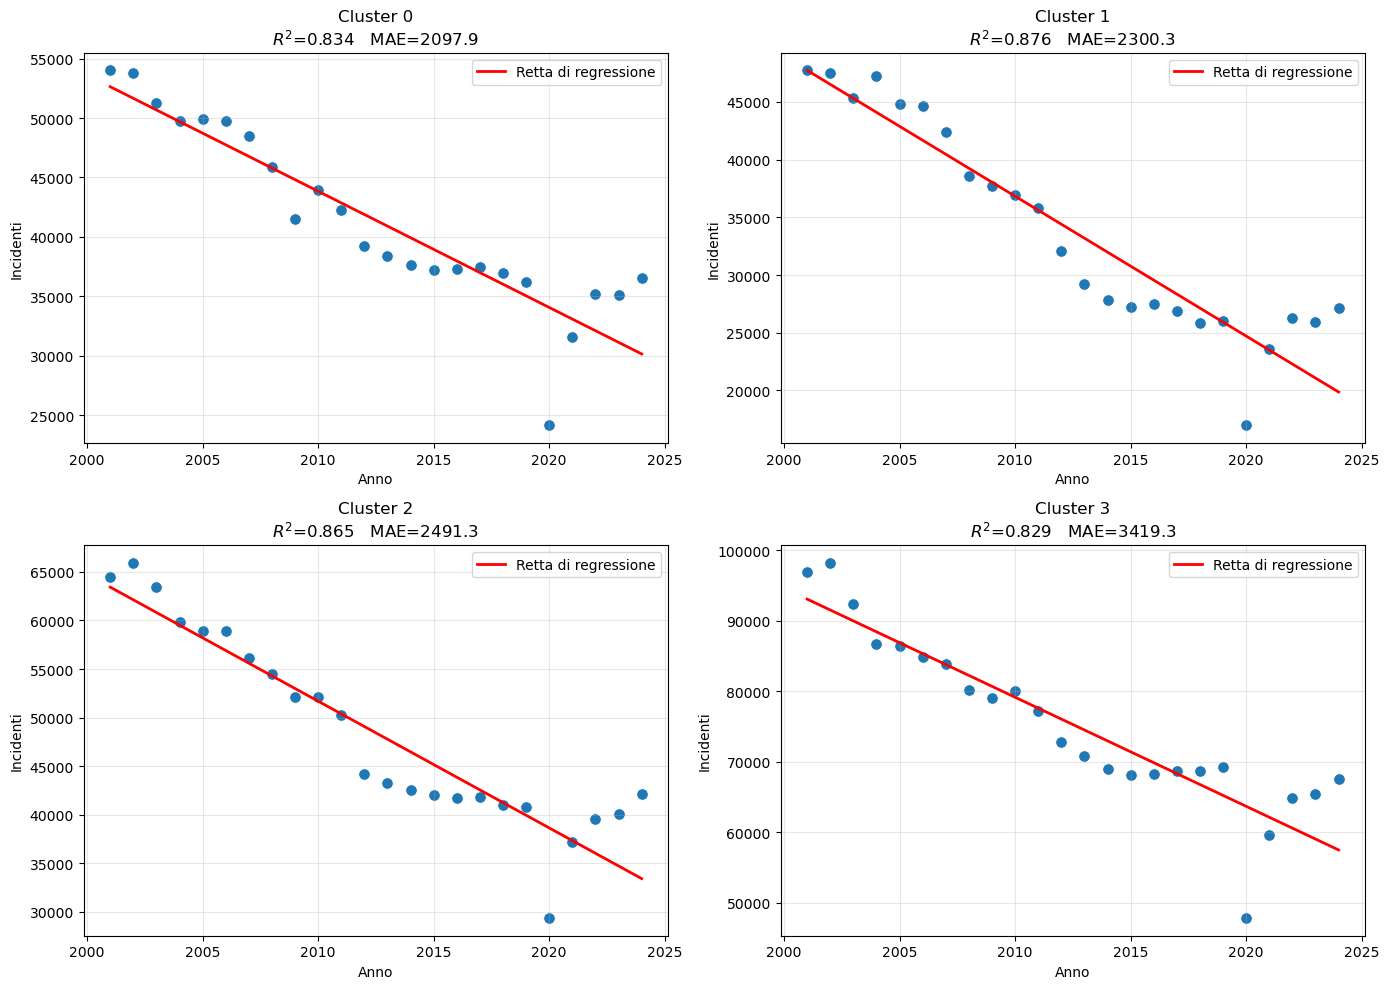

In [397]:
# CLUSTERING DEI COMUNI
# ======================================================

df_cluster = (
    df_accidents
    .groupby("ID_COMUNE", as_index=False)[
        ["RESIDENTI",
         "SUPERFICIE (KMQ)",
         "DENSITA_POPOLAZIONE"]].mean())

scaler = StandardScaler()

X_cluster = scaler.fit_transform(
    df_cluster[["RESIDENTI",
                "SUPERFICIE (KMQ)",
                "DENSITA_POPOLAZIONE"]])

kmeans = KMeans(n_clusters=4,random_state=42,n_init=10)

df_cluster["CLUSTER"] = kmeans.fit_predict(X_cluster)


# MERGE CLUSTER
# ======================================================

df_clustered = df_accidents.merge(
    df_cluster[["ID_COMUNE", "CLUSTER"]],
    on="ID_COMUNE",
    how="left")


# REGRESSIONE SUL TREND ANNUALE DEL CLUSTER
# ======================================================

fig, axes = plt.subplots(2, 2, figsize=(14,10))
axes = axes.flatten()

for cluster in sorted(df_clustered["CLUSTER"].unique()):

    # dati del cluster
    df_c = df_clustered[df_clustered["CLUSTER"] == cluster]

    # andamento annuale
    df_annuale = (
        df_c
        .groupby("TIME_PERIOD", as_index=False)["OBS_VALUE"]
        .sum()
    )

    X = sm.add_constant(df_annuale["TIME_PERIOD"])
    y = df_annuale["OBS_VALUE"]

    model = sm.OLS(y, X).fit()

    pred = model.predict(X)

    mae = mean_absolute_error(y, pred)

    print("="*70)
    print(f"CLUSTER {cluster}")
    print("="*70)
    print(f"R²                 : {model.rsquared:.4f}")
    print(f"MAE                : {mae:.2f}")
    print(f"Coefficiente anno  : {model.params['TIME_PERIOD']:.4f}")
    print(f"P-value            : {model.pvalues['TIME_PERIOD']:.5f}")
    print()

    ax = axes[cluster]

    sns.scatterplot(data=df_annuale,
                    x="TIME_PERIOD",
                    y="OBS_VALUE",ax=ax,s=70)

    ax.plot(df_annuale["TIME_PERIOD"],pred,color="red",
            linewidth=2,label="Retta di regressione")

    ax.set_title(f"Cluster {cluster}\n"
        f"$R^2$={model.rsquared:.3f}   MAE={mae:.1f}")

    ax.set_xlabel("Anno")
    ax.set_ylabel("Incidenti")

    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

# CONCLUSIONI:

L'analisi temporale evidenzia una riduzione progressiva del numero di incidenti stradali, dei feriti e dei morti nel periodo considerato. L'analisi delle variazioni percentuali mostra una marcata diminuzione nel 2020, attribuibile alle restrizioni dovute alla pandemia di COVID-19, seguita da una ripresa negli anni successivi. La regressione lineare conferma un trend decrescente statisticamente significativo, con un modello in grado di spiegare gran parte della variabilità osservata (R² = 0,860). Pur mostrando alcune limitazioni nella rappresentazione di eventi eccezionali e della dinamica temporale, il modello descrive efficacemente l'andamento generale del fenomeno.

Tuttavia, questa analisi non considera le differenze strutturali tra i comuni. Per questo motivo, nel notebook successivo viene effettuata un'analisi a livello comunale, aggregando gli incidenti sull'intero periodo e studiando come caratteristiche demografiche e territoriali influenzino l'incidentalità.